# DES and Zennaro's approach for $P_{\rm gm}$

Two ways of considering the baryonic suppression in galaxy-galaxy and galaxy-shear, in particular:
- **Zennaro:**  $P_{\rm gm} = (\sum_{ij}b_i P^{ij}_{\rm mm,DMo}) \sqrt{S} \,\,\,\,\, \rightarrow \,\,\,\,\,$ in MGL is the standard heft bias option (2) with baryons (3). Reference: https://arxiv.org/pdf/2412.08623

- **DES:**  $P_{\rm gm} = b_1 P_{\rm mm,DMo}^{\rm NL} S + $ SPT terms without baryons $ \,\,\,\,\, \rightarrow \,\,\,\,\,$ in MGL is the modified heft with Pnl (4) and baryons (3) 

# FIX THIS:
- i'm plotting the wrong thing: chose just 2-3 values of logMc and for each one of them plot the P(k) and Cls with different values of the bias parameters -> similar to the last plot in this notebook at the moment, but intead of varying logMc, vary bias
- start with galaxy-galaxy only and try to find best fit bias parameters to have a good agreement between the two models (check the plot posteriors/fixcosmo_bias_vs_baryons_lsst_3x2pt.png)

- the bias params have to remain the same in the two models
- always include baryons as you need them in the shear

In [ ]:
from matplotlib.colors import Normalize, LinearSegmentedColormap
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import MGLensing

my_colors = ['#7AC011', '#18698F', '#FF7083', '#99D4E5']

kmax07 = [482, 616, 716, 780, 818]
kmax03 = [206, 264, 306, 334, 350]
kmax01 = [68, 88, 102, 111, 116]

MGL = MGLensing.MGL("config.yaml")
# MGL Cells 
ell_l = MGL.Survey.l_wl
ell_g = MGL.Survey.l_gc
ell_x = MGL.Survey.l_xc
zz_integr = MGL.Survey.zz_integr
dndz_sources = MGL.Survey.eta_z_s
dndz_lenses = MGL.Survey.eta_z_l
nbin = MGL.Survey.nbin

Zennaro's approach

In [ ]:
params = {'Omega_m' : 0.31,
    'Omega_c'   : 0.31-0.05,
    'Omega_cb'  : 0.31,
    'sigma8_cb' : 0.83,
    'As'      : np.exp(3.07)*1.e-10,
    'Omega_b'   : 0.05,
    'ns'        : 0.96,
    'h'         : 0.68,
    'Mnu'       : 0.0,
    'w0'        : -1.0,
    'wa'        : 0.0, 
    'b1_1' : 1.187256,
    'b1_2' : 1.312369,
    'b1_3' : 1.451258,
    'b1_5' : 1.605669,
    'b1_4' : 1.777521,
    'b1L_1': 0.187684,
    'b1L_2': 0.312375,
    'b1L_3': 0.45121,
    'b1L_4': 0.60626,
    'b1L_5': 0.779385,
    'b2L_1': -0.1322075,
    'b2L_2': -0.0345375,
    'b2L_3': 0.0579305,
    'b2L_4': 0.133662,
    'b2L_5': 0.232387,
    'bs2L_1': 0.1127485,
    'bs2L_2': 0.0036835,
    'bs2L_3': -0.1261985,
    'bs2L_4': -0.285537,
    'bs2L_5': -0.406101,
    'blaplL_1': -0.100126,
    'blaplL_2': -0.1563475,
    'blaplL_3': -0.115281,
    'blaplL_4': 0.1059295,
    'blaplL_5': 0.361450,
    'a1_IA'   : 0.67,
    'eta1_IA' : 1.66,
    'beta_IA' : 0.,
    'log10Mc_bc' : 13.8,
    'eta_bc' : -0.3,
    'beta_bc' : -0.22 ,
    'log10Mz0_bc' : 10.5,
    'thetaout_bc' : 0.25,
    'thetainn_bc' : -0.86,
    'log10Minn_bc' : 12.4,
}     
model_sqrt = {'nl_model' : 1, 'cross_sqrt_baryon' : True, 'bias_model' : 2, 'baryon_model' : 3, 'ia_model' : 0, 'photoz_err_model' : 0}

k_arr, pmm_sqrt, pgm_sqrt, pgg_sqrt = MGL.get_power_spectra(params, model_sqrt)

DES approach

In [ ]:
model_des = {'nl_model' : 1, 'cross_sqrt_baryon' : False, 'bias_model' : 4, 'baryon_model' : 3, 'ia_model' : 0, 'photoz_err_model' : 0}

_, pmm_des, pgm_des, pgg_des = MGL.get_power_spectra(params, model_des)

In [ ]:
nval = 3
pgg_bs2 = np.zeros((3, 20, 512))
pgm_bs2 = np.zeros((3, 20, 512, 5))
b2_arr = np.linspace(-0.2, 0.5, nval)
for i in range(0,nval):
    for z in range(0,nbin):
        params['b2L_'+str(z+1)] = b2_arr[i]
    _, pgg_sqrt_i, pgm_sqrt_i, _ = MGL.get_power_spectra(params, model_sqrt)
    _, pgg_des_i, pgm_des_i, _ = MGL.get_power_spectra(params, model_des)
    pgg_bs2[i], pgg_sqrt_i / pgg_des_i
    pgm_bs2[i] = pgm_sqrt_i / pgm_des_i

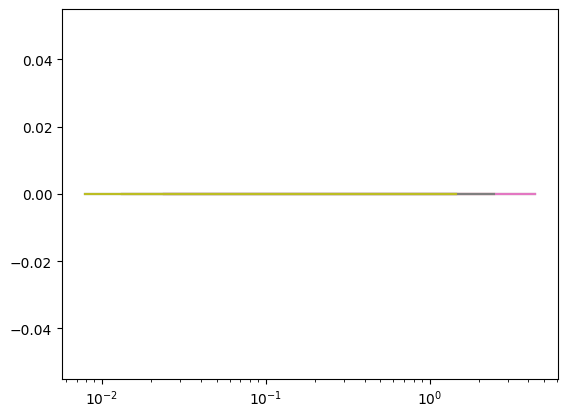

In [10]:
z_indices = [60, 120, 250] 

plt.figure()
for b in range(3):
    for i in range(len(z_indices)):
        k = k_arr[:,z_indices[i]]
        plt.plot(k, pgg_bs2[b,:,z_indices[i]])
        plt.xscale('log')
plt.show()

In [6]:
n_values = 5
logMc_arr = np.linspace(9., 15., n_values)
cl_gl_sqrt = np.zeros((n_values, len(ell_x), nbin, nbin))
cl_gl_des = np.zeros((n_values, len(ell_x), nbin, nbin))
for i in range(n_values):
    params['log10Mc_bc'] = logMc_arr[i]
    _, _, _, cl_gl_sqrt[i] = MGL.get_c_ells(params, model_sqrt)
    _, _, _, cl_gl_des[i] = MGL.get_c_ells(params, model_des)

model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...


/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0.2 when using version 1.5.2. This might lead to

Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...


KeyboardInterrupt: 

In [ ]:
# n_values = 5
# logMc_arr = [13.8] # np.linspace(9., 15., 3)
# mc_values = len(logMc_arr)
# b1_arr = np.linspace(.1, 1.5, n_values)
# b2_arr = np.linspace(-1.5, 1.5, n_values)
# bs2_arr = np.linspace(-0.2, 0.5, n_values)
# blap_arr = np.linspace(-0.2, 0.5, n_values)

# cl_gg_sqrt = np.zeros((mc_values, n_values, len(ell_x), nbin, nbin))
# cl_gl_sqrt = np.zeros((mc_values, n_values, len(ell_x), nbin, nbin))
# cl_gg_des = np.zeros((mc_values, n_values, len(ell_x), nbin, nbin))
# cl_gl_des = np.zeros((mc_values, n_values, len(ell_x), nbin, nbin))
# for m in range(mc_values):
#     params['log10Mc_bc'] = logMc_arr[m]
#     for i in range(n_values):
#         params['']
#         _, cl_gg_sqrt[m][i], _, cl_gl_sqrt[m][i] = MGL.get_c_ells(params, model_sqrt)
#         _, cl_gg_des[m][i], _, cl_gl_des[m][i] = MGL.get_c_ells(params, model_des)

## Galaxy-matter power spectra (example with logMc = 13.8)

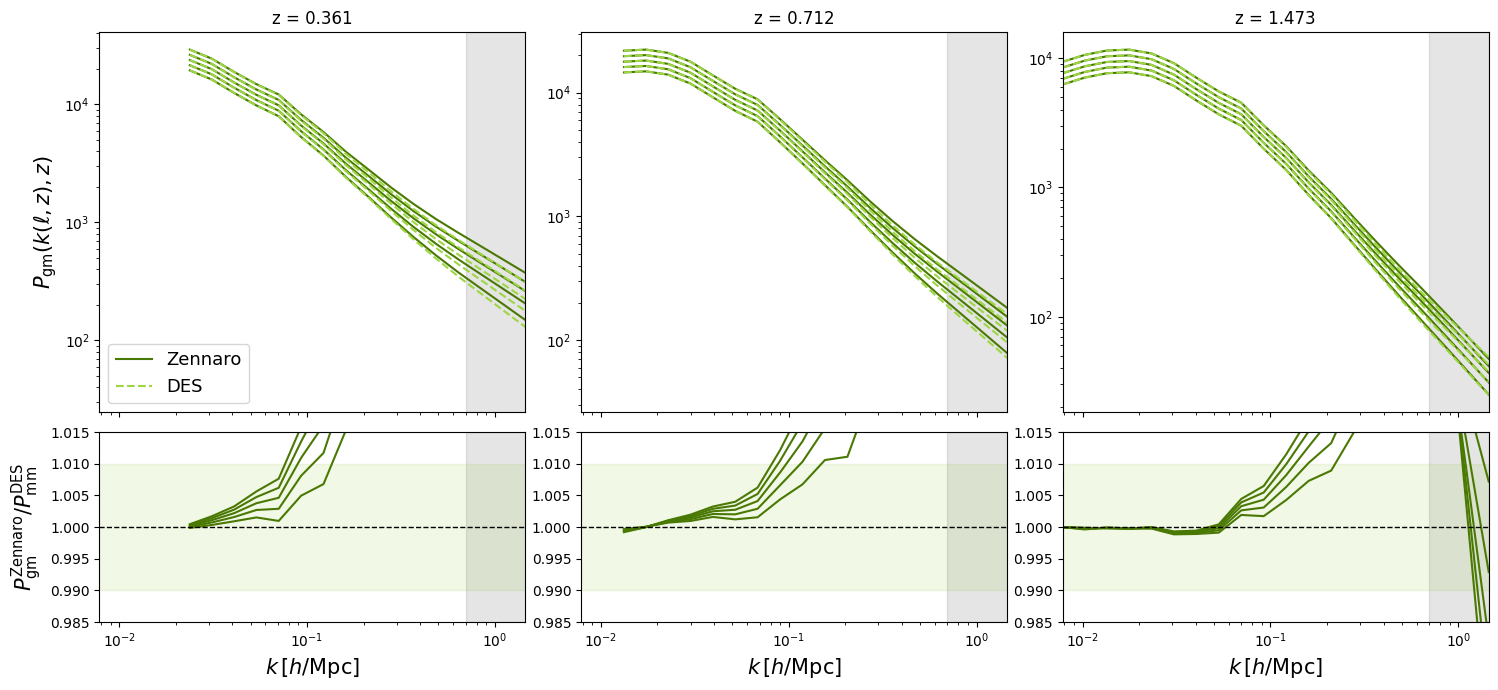

In [ ]:
z_indices = [60, 120, 250] 

fig, ax = plt.subplots(2, 3, figsize=(15, 7), facecolor='w', gridspec_kw={'height_ratios':[2,1] }, sharex=True)
for i in range(len(z_indices)):
    k = k_arr[:,z_indices[i]]
    for b in range(nbin):
        ax[0][i].loglog(k, pgm_sqrt[:,z_indices[i],b], color="#4A7903", linestyle='-')
        ax[0][i].loglog(k, pgm_des[:,z_indices[i],b], color="#9CD743", linestyle='--')
    ax[0][i].axvspan(0.7, k[-1], color='k', alpha=0.1, label='_nolegend_')
    ax[0][i].set_title(f'z = {zz_integr[z_indices[i]]:.3f}')                                    
    #
    for b in range(nbin):
        ax[1][i].plot(k, pgm_sqrt[:,z_indices[i],b]/pgm_des[:,z_indices[i],b], color='#4A7903')
    ax[1][i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
    ax[1][i].set_xlabel(r'$k\, [h/\rm Mpc]$', fontsize=15)
    ax[1][i].axvspan(0.7, k[-1], color='k', alpha=0.1, label='_nolegend_')
    ax[1][i].axhspan(0.99, 1.01, color='#7AC011', alpha=0.1, label='_nolegend_')
    ax[1][i].set_xlim(k[0], k[-1])
    ax[1][i].set_ylim(0.985, 1.015)
legend = ['Zennaro', 'DES']
ax[0][0].legend(legend, fontsize=13)
ax[0][0].set_ylabel(r"$P_{\rm gm}(k(\ell, z), z)$", fontsize=15)
ax[1][0].set_ylabel(r"$P^{\rm Zennaro}_{\rm gm}/P_{\rm mm}^{\rm DES}$", fontsize=15)
plt.tight_layout()

## Angular power spectra

Text(0.5, 0.04, '$\\ell$')

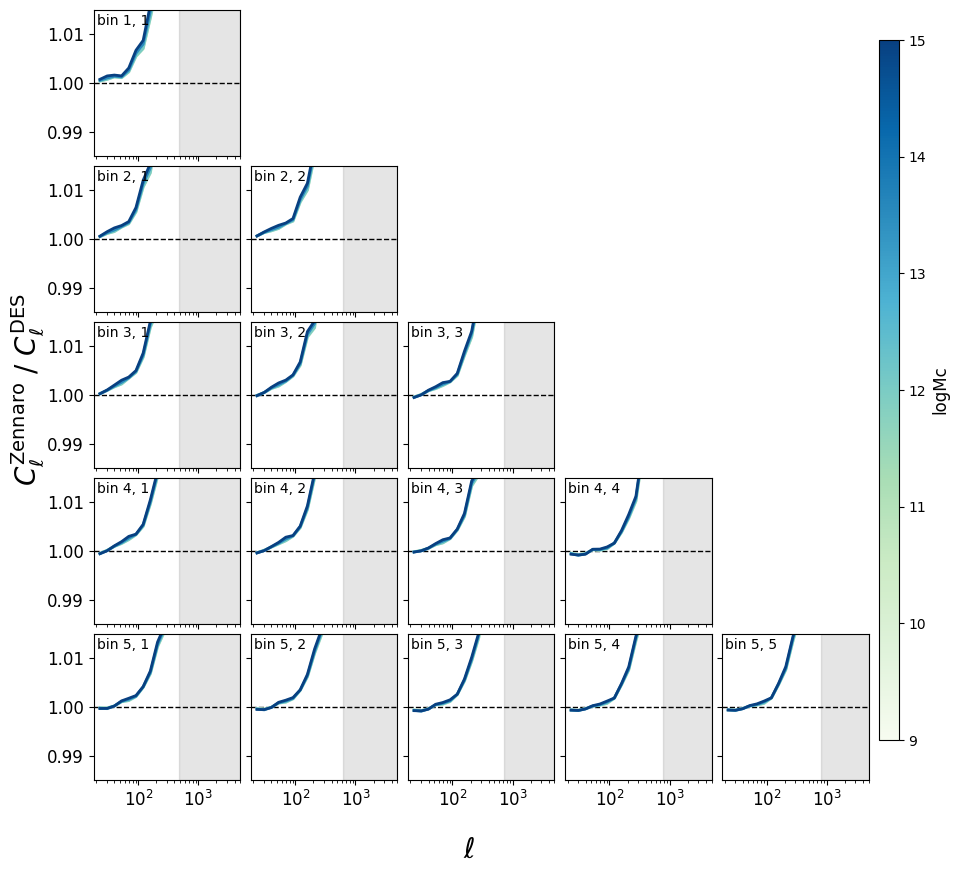

In [ ]:
ell_cuts = [kmax07]
ell_list = [ell_l, ell_g, ell_x]
fig, ax = plt.subplots(nbin, nbin, figsize=(10, 10), sharey='row', sharex=True)
cmap = sns.color_palette("GnBu", as_cmap=True)
# normalize parameter values for the colormap
norm = Normalize(vmin=min(logMc_arr), vmax=max(logMc_arr))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 

fig.subplots_adjust(wspace=0.07, hspace=0.07)
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            ax[i][j].axhline(y=1.0, color='k', linestyle='--', linewidth=1, label='_nolegend_')   
            for c in range(n_values):
                color = cmap(norm(logMc_arr[c]))
                ax[i,j].plot(ell_x, cl_gl_sqrt[c][:,i,j]/cl_gl_des[c][:,i,j], color=color, linewidth=2)
            ax[i,j].set_xscale('log')
            ax[i,j].text(.2, .9, f'bin {i+1}, {j+1}', fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)  
            ax[i,j].tick_params(axis='both', which='major', labelsize=12)        
            ax[i,j].set_xlim(18, 5000)
            ax[i,j].set_ylim(0.985, 1.015)
            for cuts in ell_cuts:
                ax[i,j].axvspan(5000, cuts[j], color='k', alpha=0.1, label='_nolegend_') #GG cuts
        else:
            ax[i,j].axis('off')
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('logMc', fontsize=12)
fig.text(0.06, 0.5, r'$C_\ell^{\rm Zennaro}$ / $C_\ell^{\rm DES}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)  
# plt.tight_layout()